#15.773 Homework 2 (Spring 2026): Natural Langugage Processing

Student: Roman Burdakov

-----
**IMPORTANT: Choose a T-4 GPU with High-RAM or an A100 GPU**
-----

Install the `keras-hub` package so that we can access pretrained Transformer models.

In [ ]:
!pip install --upgrade keras-hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.9 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.10.0
    Uninstalling keras-3.10.0:
      Successfully uninstalled keras-3.10.0
  Attempting uninstall: keras-hub
    Found existing installation: keras-hub 0.21.1
    Uninstalling keras-hub-0.21.1:
      Successfully uninstalled keras-hub-0.21.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.21.1 requires keras-hub==0.21.1, but you have keras-hub 0.26.0 which is incompatible.


In [ ]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import keras

keras.utils.set_random_seed(42)

# Introduction

This homework assignment will ask you to build models using (1) the Bag-of-Words approach and (2) and by fine-tuning BERT.

We will work with a famous dataset in natural langauge processing called **20 Newsgroup**,  which consists of posts from an online forum under certain topics such as politics, religion, sports...etc. As the name suggests, there are a total of 20 topics in this dataet. The 20 Newsgroup dataset is a popular benchmark for text classification algorithms.

The entire dataset is quite large. To ensure training takes a reasonable amount of time, we will only choose 6 out of the 20 topics, including topics like religion, space (astronomy) and medicine.

In [ ]:
from sklearn.datasets import fetch_20newsgroups

newsgroups_train = fetch_20newsgroups(subset='train', categories = ['alt.atheism', 'talk.religion.misc', 'comp.graphics', 'sci.space', 'sci.med', 'rec.autos'])
newsgroups_test = fetch_20newsgroups(subset='test', categories = ['alt.atheism', 'talk.religion.misc', 'comp.graphics', 'sci.space', 'sci.med', 'rec.autos'])

train_df = pd.DataFrame({'text': newsgroups_train.data, 'label': newsgroups_train.target})
test_df = pd.DataFrame({'text': newsgroups_test.data, 'label': newsgroups_test.target})

print(f"""
Train samples: {train_df.shape[0]}
Test samples: {test_df.shape[0]}
""")

train_df.head(10)


Train samples: 3222
Test samples: 2145



,text,label
0,From: boylan@pi.eai.iastate.edu (Terran Boylan...,1
1,From: I3150101@dbstu1.rz.tu-bs.de (Benedikt Ro...,0
2,From: snichols@adobe.com (Sherri Nichols)\nSub...,3
3,From: johnm@spudge.lonestar.org (John Munsch)\...,1
4,From: Nanci Ann Miller <nm0w+@andrew.cmu.edu>\...,0
5,From: nsmca@aurora.alaska.edu\nSubject: 30826\...,4
6,From: geb@cs.pitt.edu (Gordon Banks)\nSubject:...,3
7,From: higgins@fnalf.fnal.gov (Bill Higgins-- B...,4
8,From: mmm@cup.portal.com (Mark Robert Thorson)...,3
9,From: daniel@lclark.edu (Daniel Snodgrass)\nSu...,1


The distribution of labels across these 6 classes is fairly balanced.



In [ ]:
train_df['label'].value_counts() / train_df.shape[0]

,count
label,
2,0.184358
3,0.184358
4,0.184047
1,0.181254
0,0.148976
5,0.117008


Let's convert our dependent variable into a 1-hot-encoded vector.

In [ ]:
# Let's turn the target into a dummy vector
y_train = pd.get_dummies(train_df['label'], dtype="int").to_numpy()
y_test = pd.get_dummies(test_df['label'], dtype="int").to_numpy()

y_train[:10]

array([[0, 1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 1, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 1, 0, 0, 0, 0]])

# Problem 1: Bag-of-Words (BoW) Model [50 Points]

In this problem, we will build a bag-of-words model using the text vectorization capabilities of Keras. We will then change some of the parameters of this vectorization process and see how it changes the performance.



## Part (a): Build a Base Model [15 Points]

**Text Vectorization**

Please fill in the code in the following cell. We would like to create a text vectorization layer which uses:

* Maximum of 2000 tokens.
* Unigrams
* Outputs a multi-hot encoded BoW encoding
* Converts text to lower case and strips punctuation

In [ ]:
# Set the maximum number of tokens (which is the size of the vocabulary) to 2000
max_tokens = 2000

# Configure the text vectorization layer

text_vectorization = keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="multi_hot"
)

# Let's adapt the Text Vectorization layer using the training corpus
text_vectorization.adapt(train_df['text'])

# We vectorize our input with the adapted Text Vectorization layer
X_train = text_vectorization(train_df['text'])
X_test = text_vectorization(test_df['text'])

pd.DataFrame(X_train, columns = text_vectorization.get_vocabulary())

,[UNK],the,of,to,a,and,in,is,i,that,...,loving,learning,jaegerbuphybuedu,hour,helps,glutamate,finding,delta,careful,bother
0,1,1,1,1,1,1,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,1,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,0
2,1,1,0,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3217,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3218,1,1,1,1,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3219,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3220,1,1,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0


In the following cell, please build a simple Neural Network with a single hidden layer of 128 neurons with ReLu activation. Be sure to specify the shape of the input correctly and use the appropriate activation function for the output. Your model should have 256902 parameters. The code for compiling has been written for you already.

In [ ]:
### YOUR CODE BELOW ###
inputs = keras.layers.Input(shape=(max_tokens, ))
x = keras.layers.Dense(128, activation="relu")(inputs)
outputs = keras.layers.Dense(y_train.shape[1], activation="softmax")(x) # 6 categories in output

### YOUR CODE ABOVE ###

bow_model = keras.Model(inputs, outputs)
bow_model.summary()

bow_model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy']
)

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 2000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       256,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 256,902 (1003.52 KB)

 Trainable params: 256,902 (1003.52 KB)

 Non-trainable params: 0 (0.00 B)

A theme that we will be investigating in this homework is the **impact of the number of training examples on the different models**. As a result, in addition to training the model on all 3000+ training examples, we will also test how our model performs with only 200 examples.

The code below shows a fitting process in which we first fit model `bow_model` to the first 200 examples from the training set `(X_train[:200], y_train[:200]`). We print the accuracy of the model on the test set. Then, we run the training procedure for another 20 epochs, this time with the full data set `(X_train, y_train`). You just need to run the cell.

In [ ]:
# Fit model on the training data with 20 epochs and batch size of 32
bow_model.fit(
    x=X_train[:200], y=y_train[:200],
    epochs=20, batch_size=32,
    verbose=1,
)

print(f"*** Test accuracy with 200 examples:{bow_model.evaluate(x=X_test, y=y_test)[1]:.2%} ***")


# Fit model on the training data with 20 epochs and batch size of 32
bow_model.fit(
    x=X_train, y=y_train,
    epochs=20, batch_size=32,
    verbose=1,
)

print(f"*** Test accuracy with ALL examples:{bow_model.evaluate(x=X_test, y=y_test)[1]:.2%} ***")

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.2450 - loss: 1.7635
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9300 - loss: 1.1729 
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9950 - loss: 0.7977 
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.5110 
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.3172 
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.1979 
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.1266 
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0847 
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0597 
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0441 
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0340 
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0271 
E

**<font color='red'>Please Answer Below</font>**

BoW Base Model
* Test accuracy with 200 Examples: **63.82%**
* Test accuracy with All Examples: **82.84%**

Briefly comment on if the accuracy numbers are surprising or unsurprising.

_The results are unsurprising. Given that the categories are largely distinguished by a topic-specific vocabulary (many differentiating signal words for each category), even the simple model can do quite well on 20 Newsgroups. When we train on the full dataset, the test accuracy is closer to what we would expect for this kind of baseline._

What is the baseline performance by predicting the most frequent class?

_Given the class distribution, the most frequent category shows up about 0.184358 ≈ 18.44% of the time. A baseline predictor for most frequent answer would get roughly ~18.44% accuracy._


## Part (b): Explore Hyperparameters [35 Points]

Now, let us try changing some of the hyperparameters in the text vectorization process.

* Use bigrams instead of unigrams.
* Increase the maximum number of tokens from 2000 to 5000
* Use count encoding instead of multi-hot encoding

For each of the above modifications,
* modify the code cell below (feel free to copy-paste the code from above)
* run the code cell and
* report the test accuracy.

<font color='red'>Note that you should make each change independent of the other two changes. When you are done, you should have 3 versions of the code cell below.</font>




In [ ]:
max_tokens = 2000

text_vectorization = keras.layers.TextVectorization(
    ngrams=2,
    max_tokens=max_tokens,
    output_mode="multi_hot"
)

text_vectorization.adapt(train_df['text'])

X_train = text_vectorization(train_df['text'])
X_test = text_vectorization(test_df['text'])

### YOUR CODE BELOW ###
inputs = keras.layers.Input(shape=(max_tokens, ))
x = keras.layers.Dense(128, activation="relu")(inputs)
outputs = keras.layers.Dense(y_train.shape[1], activation="softmax")(x) # 6 categories in output
### YOUR CODE ABOVE ###

bow_model = keras.Model(inputs, outputs)
bow_model.summary()

bow_model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy']
)

bow_model.fit(
    x=X_train[:200], y=y_train[:200],
    epochs=20, batch_size=32,
    verbose=1,
)
print("\n*** Test accuracy with 200 Examples: %.4f ***\n" % bow_model.evaluate(x=X_test, y=y_test)[1])

bow_model.fit(
    x=X_train, y=y_train,
    epochs=20, batch_size=32,
    verbose=1,
)
print("\n*** Test accuracy with All Examples % .4f ***\n" % bow_model.evaluate(x=X_test, y=y_test)[1])

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 2000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │       256,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 256,902 (1003.52 KB)

 Trainable params: 256,902 (1003.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.2650 - loss: 1.7579
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9250 - loss: 1.0433 
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9850 - loss: 0.6539 
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.3988 
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.2419 
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.1497 
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0962 
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0650 
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0464 
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0348 
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0273 
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0221 
E

In [ ]:
max_tokens = 5000

text_vectorization = keras.layers.TextVectorization(
    ngrams=1,
    max_tokens=max_tokens,
    output_mode="multi_hot"
)

text_vectorization.adapt(train_df['text'])

X_train = text_vectorization(train_df['text'])
X_test = text_vectorization(test_df['text'])

### YOUR CODE BELOW ###
inputs = keras.layers.Input(shape=(max_tokens, ))
x = keras.layers.Dense(128, activation="relu")(inputs)

outputs = keras.layers.Dense(y_train.shape[1], activation="softmax")(x) # 6 categories in output
### YOUR CODE ABOVE ###

bow_model = keras.Model(inputs, outputs)
bow_model.summary()

bow_model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy']
)

bow_model.fit(
    x=X_train[:200], y=y_train[:200],
    epochs=20, batch_size=32,
    verbose=1,
)
print("\n*** Test accuracy with 200 Examples: %.4f ***\n" % bow_model.evaluate(x=X_test, y=y_test)[1])

bow_model.fit(
    x=X_train, y=y_train,
    epochs=20, batch_size=32,
    verbose=1,
)
print("\n*** Test accuracy with All Examples % .4f ***\n" % bow_model.evaluate(x=X_test, y=y_test)[1])

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 640,902 (2.44 MB)

 Trainable params: 640,902 (2.44 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.3550 - loss: 1.7364
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9850 - loss: 1.0044 
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.5514 
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.2821 
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.1443 
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0790 
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0471 
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0310 
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0221 
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0169 
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0135 
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0112 
E

In [ ]:
max_tokens = 2000

text_vectorization = keras.layers.TextVectorization(
    ngrams=1,
    max_tokens=max_tokens,
    output_mode="count"
)

text_vectorization.adapt(train_df['text'])

X_train = text_vectorization(train_df['text'])
X_test = text_vectorization(test_df['text'])

### YOUR CODE BELOW ###
inputs = keras.layers.Input(shape=(max_tokens, ))
x = keras.layers.Dense(128, activation="relu")(inputs)

outputs = keras.layers.Dense(y_train.shape[1], activation="softmax")(x) # 6 categories in output
### YOUR CODE ABOVE ###

bow_model = keras.Model(inputs, outputs)
bow_model.summary()

bow_model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy']
)

bow_model.fit(
    x=X_train[:200], y=y_train[:200],
    epochs=20, batch_size=32,
    verbose=1,
)
print("\n*** Test accuracy with 200 Examples: %.4f ***\n" % bow_model.evaluate(x=X_test, y=y_test)[1])

bow_model.fit(
    x=X_train, y=y_train,
    epochs=20, batch_size=32,
    verbose=1,
)
print("\n*** Test accuracy with All Examples % .4f ***\n" % bow_model.evaluate(x=X_test, y=y_test)[1])

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 2000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │       256,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 256,902 (1003.52 KB)

 Trainable params: 256,902 (1003.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.1950 - loss: 2.4272
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6250 - loss: 1.3103 
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8600 - loss: 0.8561 
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9500 - loss: 0.5865 
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9900 - loss: 0.4033 
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.2932 
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.2127 
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.1561 
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.1162 
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0876 
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0670 
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0521 
E

**<font color='red'>Please Answer Below</font>**

Fill in the blanks with the test accuracies you obtained from re-running Problem 1(a)'s code with the relevant modifications.

For each of the 3 modifications, briefly comment on why one might expect such a change to be beneficial. Using the numbers above, comment on whether it improved, hurt or didn't affect the model's performance.

* Bigrams instead of unigrams
  * 200 Training Examples: **56.41%**
  * All Training Examples: **77.67%**
  * Comment: _Bigrams expanded sparsity and with limited data many informative bigrams are became mroe rare, increasing overfitting and reducing generalization. Here it hurt performance (56.41% / 63.82%) compare to the BoW baseline for 200 samples and also for all samples (77.67% vs 82.84% for the BoW baseline)_
* Increasing max_tokens to 5000.
  * 200 Training Examples: **66.11%**
  * All Training Examples: **87.32%**
  * Comment: _A larger vocabulary retains more informative words, reducing information loss from aggressive truncation. The extra features added useful signal more than noise, especially when enough training data is available which increased accuracy (87.32% vs 82.84% )_
* Count instead of multi-hot
  * 200 Training Examples: **63.12%**
  * All Training Examples: **82.70%**
  * Comment: _Count features (output_mode) preserves frequency information, which can provide additional signal beyond simple presence/absence. However, in this particular case, this didn't materially change accuracy compare to baseline model from part a. (63.12% / 63.82% for 200 samples and 82.70% / 82.84% for all) If anything, it made it a bit less accurate for both training sets_



# Problem 2: BERT Transformer Model [50 Points]

In this problem, you will demonstrate how using a pre-trained model like [Bert](https://en.wikipedia.org/wiki/BERT_(language_model)) can yield high accuracy with as little as 200 examples.

## Setup

### Get access to Keras Hub pretrained models

Follow these instructions before continuing with the Colab. This is a one-time thing and will be useful in future colabs as well.

* Go to [kaggle.com](https://kaggle.com) and create an account.
* Go to the **Account** tab of your Kaggle user profile and select **Create New Token**. This will trigger the download of a `kaggle.json` file containing your Kaggle username and Kaggle API key.
* Open this file using a text editor.
* In Colab, select **Secrets** (the key image) in the left pane.  
* Click "Add new secret"
* Copy your Kaggle username from the text editor and store it under the name `KAGGLE_USERNAME`.  
* Click "Add new secret"
* Copy your Kaggle API key from the text editor and store it under the name `KAGGLE_KEY`.
* Toggle "Notebook Access" to ON for both.

When you are done, it should look something like this:



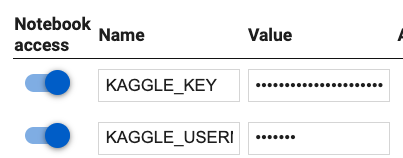

In [ ]:
import keras_hub

We will download Bert from the Keras Hub model repository. This will take a minute or two the first time you do it.

In [ ]:
bert = keras_hub.models.BertClassifier.from_preset(
    "bert_base_en_uncased",
    activation="softmax",
    num_classes=6
)

Take a look at Bert's architecture.

In [ ]:
bert.summary()

Preprocessor: "bert_text_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ bert_tokenizer (BertTokenizer)                                │                       Vocab size: 30,522 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "bert_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ segment_ids (InputLayer)      │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bert_backbone (BertBackbone)  │ [(None, 768), (None,      │     109,482,240 │ padding_mask[0][0],        │
│                               │ None, 768)]               │                 │ segment_ids[0][0],         │
│                               │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ classifier_dropout (Dropout)  │ (None, 768)               │               0 │ bert_backbone[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 6)                 │           4,614 │ classifier_dropout[0][0]   │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 109,486,854 (417.66 MB)

 Trainable params: 109,486,854 (417.66 MB)

 Non-trainable params: 0 (0.00 B)

109 million parameters!!

In lecture we showed how to finetune this model end-to-end. Here, we show a different way to use BERT: we will take the BERT backbone, run our data through it and get the embedding for the CLS token for each data point, and then use that as the input for our own, little MLP.

Here's the backbone.

In [ ]:
bert.backbone.summary()

Model: "bert_backbone"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_ids           │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_embedding     │ (None, None, 768) │ 23,440,896 │ token_ids[0][0]   │
│ (ReversibleEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ segment_ids         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_embedding  │ (None, None, 768) │    393,216 │ token_embedding[… │
│ (PositionEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ segment_embedding   │ (None, None, 768) │      1,536 │ segment_ids[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embeddings_add      │ (None, None, 768) │          0 │ token_embedding[… │
│ (Add)               │                   │            │ position_embeddi… │
│                     │                   │            │ segment_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embeddings_layer_n… │ (None, None, 768) │      1,536 │ embeddings_add[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embeddings_dropout  │ (None, None, 768) │          0 │ embeddings_layer… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ padding_mask        │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_0 │ (None, None, 768) │  7,087,872 │ embeddings_dropo… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_1 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_2 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_3 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_4 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_5 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_6 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 109,482,240 (417.64 MB)

 Trainable params: 109,482,240 (417.64 MB)

 Non-trainable params: 0 (0.00 B)

Notice that what comes out of the backbone is a 768-long vector. This is the embedding of the CLS token.

This will be the input to our MLP.

## Run datasets through the BERT backbone

Step 1: We need to run our data through the BERT backbone and get the embedding for the CLS token for each data point.

The code cell below does this for the training dataset.

In [ ]:
tokenized_input = bert.preprocessor(train_df.text)
bert_output = bert.backbone.predict(tokenized_input)['sequence_output'][:, 0, :]

101/101 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step


Your turn: Do what we did above, for the test set.

In [ ]:
test_tokenized_input = bert.preprocessor(test_df.text)
test_bert_output = bert.backbone.predict(test_tokenized_input)['sequence_output'][:, 0, :]

68/68 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step


## Finetune on 200 examples

Define a neural network with 2 dense layers of 128 neurons each using a ReLU activation. Each dense layer should be followed by a Dropout layer with probability of 0.1.

In [ ]:
### YOUR CODE BELOW ###

inputs = keras.layers.Input(shape=(bert_output.shape[1],))
x = keras.layers.Dense(128, activation="relu")(inputs)
x = keras.layers.Dropout(0.1)(x)
x = keras.layers.Dense(128, activation="relu")(x)
x = keras.layers.Dropout(0.1)(x)
output = keras.layers.Dense(y_train.shape[1], activation="softmax")(x)

### YOUR CODE ABOVE ###


# Model
bert_finetuned = keras.Model(inputs, output)

In [ ]:
bert_finetuned.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,718 (452.02 KB)

 Trainable params: 115,718 (452.02 KB)

 Non-trainable params: 0 (0.00 B)

**How many parameters does your model have: 115,718**

*Answer: 115,718*

Let's compile and train it.

In [ ]:
bert_finetuned.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

bert_finetuned.fit(x=bert_output[:200],
                   y=y_train[:200],
                   epochs=20,
                   batch_size=32,verbose=1,
)

accuracy_200 = bert_finetuned.evaluate(x=test_bert_output, y=y_test)[1]
print(f"*** Test accuracy with 200 Examples: {accuracy_200:.2%} ***")

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step - accuracy: 0.2450 - loss: 1.7763
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4100 - loss: 1.5431 
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6150 - loss: 1.3251 
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7400 - loss: 1.1052 
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7750 - loss: 0.8806 
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8200 - loss: 0.7487 
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8300 - loss: 0.6280 
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8250 - loss: 0.5250 
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9000 - loss: 0.3867 
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9050 - loss: 0.3411 
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9100 - loss: 0.3082 
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9300 - loss: 0.2424 


## Fine-tune on ALL examples

Your turn: Compile and train the model on ALL examples. Use the same batch size and number of epochs as above.

In [ ]:
## YOUR CODE BELOW ##

bert_finetuned.fit(x=bert_output, y=y_train,
                   epochs=20,
                   batch_size=32,verbose=1,
)

## YOUR CODE ABOVE ##


accuracy_ALL = bert_finetuned.evaluate(x=test_bert_output, y=y_test)[1]
print(f"*** Test accuracy with ALL Examples: {accuracy_ALL:.2%} ***")

Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8029 - loss: 0.5328
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8482 - loss: 0.4018
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8746 - loss: 0.3482
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8914 - loss: 0.2922
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9010 - loss: 0.2657
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9078 - loss: 0.2361
Epoch 7/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9240 - loss: 0.2089
Epoch 8/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9258 - loss: 0.1912
Epoch 9/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9354 - loss: 0.1698
Epoch 10/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9410 - loss: 0.1617
Epoch 11/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9429 - loss: 0.1378
Epoch 12/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/ste

<font color='red'>**Please Answer Below**</font>

Fill in the table below with the accuracies from above.

The base BoW Model:
* Test accuracy with 200 Examples: **63.82%**
* Test accuracy with All Examples: **82.84%**


BERT Model Accuracy
* Test accuracy with 200 Examples: **74.36%**
* Test accuracy with All Examples: **81.59%**


Comment on the performance of the BERT-based model relative to the BoW model.

_As expected, the BERT-based model outperforms BoW in the low-data setting (74.36% for BERT vs 63.82% for BoW with 200 examples), because pretrained BERT embeddings transfer useful language structure even with limited labeled data. However, with all training examples, the BoW model is slightly better (82.84% for BoW vs 81.59% for BERT). This is liekly because topic classification is very keyword-driven and BoW can leverage dataset-specific vocabulary extremely well, vs BERT approach which is based on frozen backbone embeddings plus a small head, which may not adapt as effectively as either BoW on this task or true end-to-end BERT fine-tuning._
